# 3 · Ligand–receptor niche maps

Infer spatially-resolved **cell-cell communication** (liana + squidpy graph) and map the local signaling of the top niche cues — L-R pairs whose signaling **spatially coincides** with cardiac commitment.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")  # so `_pipeline` is importable when run from cookbook/
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import stereo_fate as sf
from _pipeline import build_result, TARGET_FATE, PROGENITOR
from pathlib import Path
FIG = Path("..") / "figures"; FIG.mkdir(exist_ok=True)
sns.set_context("talk")
# STANDING REQUIREMENT: resource guard first.
sf.check_resources(verbose=True)


stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    3.8 GB
  cpu_count      : 16
  n_jobs (capped): 15


ResourceReport(total_ram_gb=62.87113571166992, available_ram_gb=3.8420639038085938, cpu_count=16, n_jobs=15, est_dense_gb=None, fraction_of_available=None, safe=True, recommendation='ok')

In [2]:
adata = build_result()
lr = adata.uns['stereo_fate']['lr_ranking']
lr.head(10)[['rank','interaction','spatial_coincidence','effect_size','liana_specificity']]

stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    3.8 GB
  cpu_count      : 16
  n_jobs (capped): 15


,rank,interaction,spatial_coincidence,effect_size,liana_specificity
0,1,Fgf10->Fgfr2,0.434472,1.449633,3.936415e-05
1,2,Nppa->Npr1,0.423116,1.575763,1.262872e-07
2,3,Dll1->Notch1,0.376908,1.187443,2.482373e-04
3,4,Bmp10->Bmpr1a,0.370682,0.915688,5.918924e-04
4,5,Fgf8->Fgfr2,0.352057,1.152450,4.009436e-04
5,6,Wnt2->Fzd2_Lrp6,0.264218,0.434202,8.220242e-05
6,7,Fgf10->Fgfr1,0.249120,0.568682,4.945770e-06
7,8,Wnt2->Fzd4_Lrp6,0.207377,0.308096,8.220242e-05
8,9,Ghrl->Ghrhr,0.207197,0.348436,1.969062e-02
9,10,Calr->Mpl,0.200590,0.233017,4.689654e-04


### Local interaction score in space for the top coincident pairs

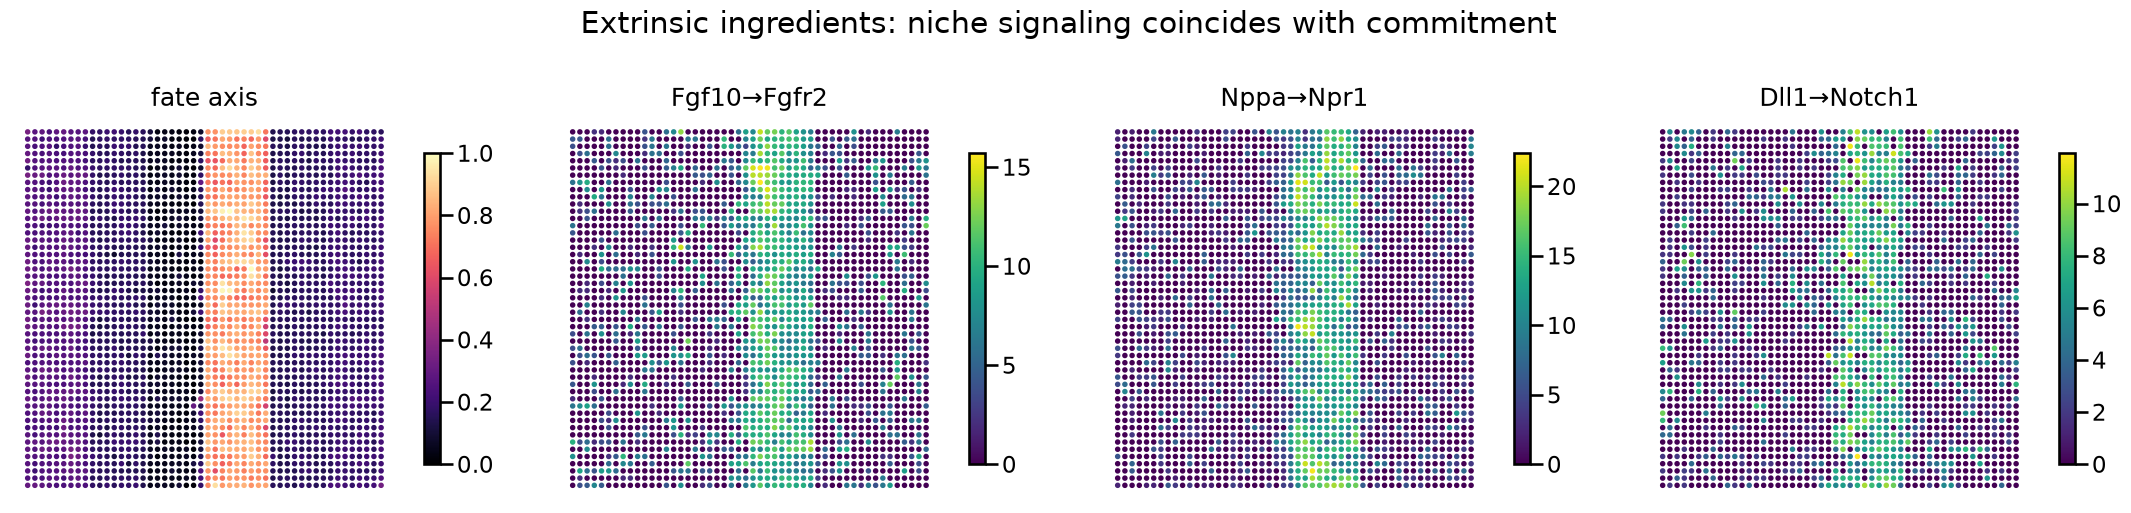

In [3]:
from scipy import sparse
import squidpy as sq
if 'spatial_connectivities' not in adata.obsp:
    sq.gr.spatial_neighbors(adata, n_neighs=6, coord_type='generic')
S=adata.obsp['spatial_connectivities'].astype(float); rs=np.asarray(S.sum(1)).ravel(); rs[rs==0]=1
def localscore(lig,rec):
    L=adata[:,lig].layers['lognorm']; R=adata[:,rec].layers['lognorm']
    L=L.toarray().ravel() if sparse.issparse(L) else np.asarray(L).ravel()
    R=R.toarray().ravel() if sparse.issparse(R) else np.asarray(R).ravel()
    return L*((S@R)/rs)
xy=adata.obsm['spatial']; pairs=list(lr[['ligand','receptor']].head(3).itertuples(index=False))
fig,axes=plt.subplots(1,4,figsize=(22,5))
s0=axes[0].scatter(xy[:,0],xy[:,1],c=adata.obs['fate_axis'],cmap='magma',s=6)
axes[0].set_title('fate axis'); plt.colorbar(s0,ax=axes[0],shrink=.8)
for ax,(lig,rec) in zip(axes[1:],pairs):
    v=localscore(lig,rec)
    sc=ax.scatter(xy[:,0],xy[:,1],c=v,cmap='viridis',s=6)
    ax.set_title(f'{lig}→{rec}'); plt.colorbar(sc,ax=ax,shrink=.8)
for ax in axes: ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
fig.suptitle('Extrinsic ingredients: niche signaling coincides with commitment', y=1.04)
fig.tight_layout(); fig.savefig(FIG/'03_lr_niche_maps.png', dpi=150, bbox_inches='tight'); plt.show()